#### Project Title: SHERLOCK TEXT GENERATOR-LSTM BASED NEXT WORD PREDICTOR
This project explores sequence-to-sequence learning using Long Short-Term Memory (LSTM) networks to generate text in the style of Sir Arthur Conan Doyle's Sherlock Holmes. We compare the performance of Bidirectional vs. Unidirectional architectures.

#### Data Preprocessing

**Boilerplate Removal**: Stripped Project Gutenberg headers/footers to prevent the model from learning legal disclaimers.

**Vectorization**: Used Tokenizer to map a vocabulary of ~9,000 words to integer sequences.

**Sliding Window**: Implemented a context window of 50 words to provide the model with enough historical data for complex sentence structures.

In [ ]:
import requests

# Fetching the Adventures of Sherlock Holmes from Project Gutenberg
url = "https://www.gutenberg.org/files/1661/1661-0.txt"
response = requests.get(url)
data = response.text

# Basic cleaning to remove Gutenberg headers/footers
start_index = data.find("To Sherlock Holmes she is always")
end_index = data.find("END OF THE PROJECT GUTENBERG EBOOK THE ADVENTURES OF SHERLOCK")
dataset = data[start_index:end_index]

In [ ]:
len(dataset)

573530

In [ ]:
dataset[7000:7500]

'u to-night, at a quarter to eight o’clock,” it\r\nsaid, “a gentleman who desires to consult you upon a matter of the very\r\ndeepest moment. Your recent services to one of the royal houses of\r\nEurope have shown that you are one who may safely be trusted with\r\nmatters which are of an importance which can hardly be exaggerated.\r\nThis account of you we have from all quarters received. Be in your\r\nchamber then at that hour, and do not take it amiss if your visitor\r\nwear a mask.”\r\n\r\n“This is indeed a mys'

In [ ]:
import re

# 1. Replace \r\n or \n with a space
cleaned_data = data.replace('\r\n', ' ').replace('\n', ' ')

# 2. Remove extra whitespace 
# This replaces multiple spaces with a single space
cleaned_data = re.sub(' +', ' ', cleaned_data)

# 3. Lowercase it
dataset = cleaned_data.lower().strip()

In [ ]:
len(dataset)

578312

In [16]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer

In [17]:
tokenizer= Tokenizer()
tokenizer.fit_on_texts([dataset])

In [ ]:
# Treated the whole text as one long sequence
all_tokens = tokenizer.texts_to_sequences([dataset])[0]

# Create sequences of a fixed length
window_size = 50
input_sequences = []
for i in range(window_size, len(all_tokens)):
    input_sequences.append(all_tokens[i-window_size:i+1])

In [20]:
vocabulary=len(tokenizer.word_index) + 1
vocabulary

8922

In [21]:
max_len = max([len(x) for x in input_sequences])

In [22]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
padded_input_sequences = pad_sequences(input_sequences, maxlen = max_len, padding='pre')

In [ ]:
padded_input_sequences

array([[4775,  157,  330, ...,   10,  124,   63],
       [ 157,  330,  885, ...,  124,   63, 2235],
       [ 330,  885,    4, ...,   63, 2235,  271],
       ...,
       [ 723,   21,   73, ...,    3,  361,   83],
       [  21,   73, 2660, ...,  361,   83,  359],
       [  73, 2660,   22, ...,   83,  359, 1673]], dtype=int32)

In [ ]:
X = padded_input_sequences[:,:-1]

In [ ]:
y = padded_input_sequences[:,-1]

In [ ]:
print(X.shape)
print(y.shape)

(111102, 50)
(111102,)


### Model 1 Architecture

1. **Embedding Layer**  
   - Converts input words into dense vectors of fixed size.

2. **Bidirectional LSTM with 300 neurons total**  
   - Processes the sequence of words in both forward and backward directions for richer context understanding. This is ideal for victorian pros where sentence meaning often depend on words appealing later in the sentence.

3. **Unidirectional LSTM(with 100 neurons)**  
   - Processes the sequence in a single direction to capture temporal dependencies.

4. **Softmax Layer**  
   - Final layer with neurons corresponding to the vocabulary, used for classification.

  Dropout layers were added in order to reduce overfitting.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout
from tensorflow.keras.optimizers import Adam
total_words = vocabulary
max_sequence_len = max_len-1

In [ ]:
model1 = Sequential()

# 1. Embedding Layer to map each word to 100-dimensional vector
model1.add(Embedding(total_words, 100, input_length=max_sequence_len-1))

# 2. Bidirectional LSTM layer
model1.add(Bidirectional(LSTM(150, return_sequences=True)))
model1.add(Dropout(0.2)) # to prevent overfitting

# 3. Second layer: Unidirectional LSTM
model1.add(LSTM(100))
model1.add(Dropout(0.2))

# 4. Output Softmax layer
model1.add(Dense(total_words, activation='softmax'))

opt = Adam(learning_rate=0.001, clipvalue=1.0)
model1.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model1.build(input_shape=(None, max_len-1))
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 100)        │       892,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 50, 300)        │       301,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 300)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8922)           │       901,122 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,254,922 (8.60 MB)

 Trainable params: 2,254,922 (8.60 MB)

 Non-trainable params: 0 (0.00 B)

#### If loss does not reduce for 10 consecutive epochs or the model is stuck on plateaus, early stopping and reduced learning rate will be applied.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Stop training if loss doesn't improve for 10 epochs
early_stop = EarlyStopping(
    monitor='loss',
    patience=10,
    restore_best_weights=True
)

# Lower the learning rate if the model hits a plateau
reduce_lr = ReduceLROnPlateau(
    monitor='loss',
    factor=0.2,
    patience=5,
    min_lr=0.0001
)

callbacks = [early_stop, reduce_lr]

In [ ]:
# For bidirectional LSTM
history1 = model1.fit(
    X, y,
    epochs=100,
    batch_size=100,
    callbacks=callbacks
)

Epoch 1/100
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.0567 - loss: 6.5598 - learning_rate: 0.0010
Epoch 2/100
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - accuracy: 0.0829 - loss: 6.0441 - learning_rate: 0.0010
Epoch 3/100
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.1022 - loss: 5.8181 - learning_rate: 0.0010
Epoch 4/100
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - accuracy: 0.1162 - loss: 5.6294 - learning_rate: 0.0010
Epoch 5/100
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - accuracy: 0.1252 - loss: 5.4707 - learning_rate: 0.0010
Epoch 6/100
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.1343 - loss: 5.3322 - learning_rate: 0.0010
Epoch 7/100
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - accuracy: 0.1420 - loss: 5.2093 - learning_rate: 0.0010
Epoch 8/100
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.1480 - loss: 5.0970 - learning_rate: 0.0010
Epoch 9/100
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.1527 - lo

In [ ]:
#save the model
#model1.save('Sherlock_BiLSTM.keras')

In [ ]:
from tensorflow.keras.models import load_model
model1 = load_model('Sherlock_BiLSTM.keras')

In [ ]:
# import pickle
# with open('history1_bi.pkl', 'wb') as f:
#     pickle.dump(history1.history, f)

# print("Files for history1 created in the sidebar!")

Files created in the sidebar!


In [1]:
import pickle

# Load them from the local folder
with open('history1_bi.pkl', 'rb') as f:
    history1_data = pickle.load(f)

#plot using history1_data['accuracy']

### Model 2 Architecture

1. **Embedding Layer**  
   - Converts input words into dense vector representations.

2. **Unidirectional LSTM (150 Neurons)**  
   - First LSTM layer with 150 neurons, capturing sequential dependencies in a forward direction.

3. **Unidirectional LSTM (100 Neurons)**  
   - Second LSTM layer with 100 neurons, continuing the sequence processing in a unidirectional manner.

4. **Softmax Layer**  
   - Final layer with neurons matching the vocabulary size, used for classification.

**Dropout**  
   - Dropout regularization is applied in the LSTM layers to prevent overfitting.

In [ ]:
# Clear memory from the first model
from tensorflow.keras import backend as K
K.clear_session()
model2 = Sequential()

# 1. Embedding Layer to map each word to 100-dimensional vector
model2.add(Embedding(total_words, 100, input_length=max_sequence_len-1))

# 2. Unidirectional LSTM layer
model2.add(LSTM(150, return_sequences=True))
model2.add(Dropout(0.2)) # to prevent overfitting

# 3. Second Unidirectional LSTM Layer
model2.add(LSTM(100))
model2.add(Dropout(0.2))

# 4. Output Softmax layer
model2.add(Dense(total_words, activation='softmax'))

opt = Adam(learning_rate=0.001, clipvalue=1.0)
model2.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model2.build(input_shape=(None, max_len-1))
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 100)        │       892,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50, 150)        │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 150)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │       100,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8922)           │       901,122 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,044,322 (7.80 MB)

 Trainable params: 2,044,322 (7.80 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# For unidirectional LSTM
history2 = model2.fit(
    X, y,
    epochs=100,
    batch_size=100,
    callbacks=callbacks
)

Epoch 1/100
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.0550 - loss: 6.6115 - learning_rate: 0.0010
Epoch 2/100
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.0691 - loss: 6.2028 - learning_rate: 0.0010
Epoch 3/100
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.0848 - loss: 5.9604 - learning_rate: 0.0010
Epoch 4/100
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.0984 - loss: 5.8014 - learning_rate: 0.0010
Epoch 5/100
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.1099 - loss: 5.6525 - learning_rate: 0.0010
Epoch 6/100
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.1193 - loss: 5.4942 - learning_rate: 0.0010
Epoch 7/100
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.1283 - loss: 5.3532 - learning_rate: 0.0010
Epoch 8/100
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - accuracy: 0.1338 - loss: 5.2302 - learning_rate: 0.0010
Epoch 9/100
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.1384 - lo

In [ ]:
#model2.save('Sherlock_UniLSTM.keras')

In [7]:
#load the model
from tensorflow.keras.models import load_model
model2 = load_model('Sherlock_UniLSTM.keras')

In [ ]:
# import pickle
# with open('history2_bi.pkl', 'wb') as f:
#     pickle.dump(history2.history, f)

# print("Files for history2 created in the sidebar!")

Files for history2 created in the sidebar!


In [3]:
import pickle
# Load them back from the local folder
with open('history2_bi.pkl', 'rb') as f:
    history2_data = pickle.load(f)

#plot using history1_data['accuracy']

#### Side by side comparison of Bidirectional and Unidirectional LSTM

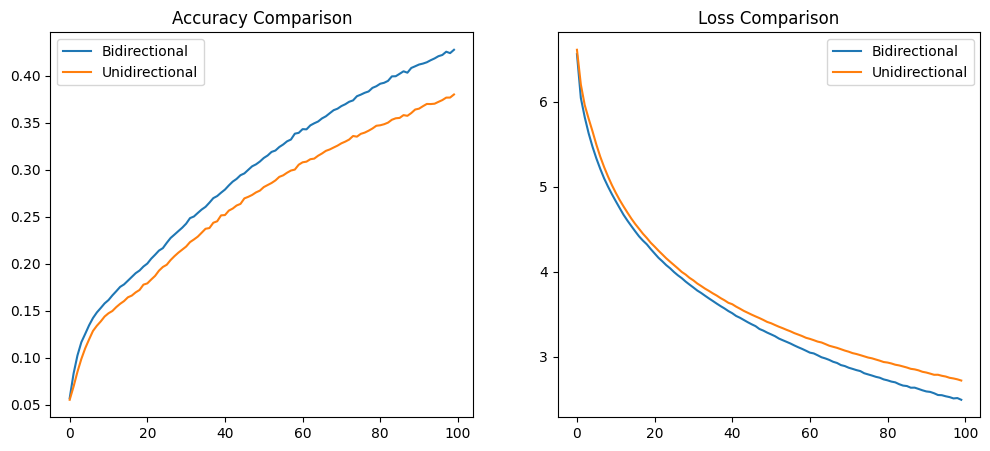

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history1_data['accuracy'], label='Bidirectional')
plt.plot(history2_data['accuracy'], label='Unidirectional')
plt.title('Accuracy Comparison')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history1_data['loss'], label='Bidirectional')
plt.plot(history2_data['loss'], label='Unidirectional')
plt.title('Loss Comparison')
plt.legend()

plt.show()

### Text Generation Techniques

To demonstrate, two different techniques were used:

1. **Text Generation with Temperature**  
   - The temperature parameter controls the creativity of the generated text:
     - **High Temperature**: Generates more creative, but often less coherent text.
     - **Low Temperature**: Produces more deterministic and predictable text, ensuring more logical coherence.
   - This technique helps prevent repetitive or boring text, striking a balance between creativity and sense-making.

2. **Text Generation with Top-k Sampling + Temperature**  
   - First, the model selects the **top k most likely words** at each step, filtering out low-probability options.
   - Then, the **temperature** parameter is applied to this filtered set of top k words to control the creativity of the selection:
     - A high temperature makes the choice more diverse, while a low temperature favors more likely words from the top k options.
   - This combination ensures that the generated text remains both relevant and creative.

In [25]:
import numpy as np

def generate_text(seed_text, next_words, model, tokenizer, max_sequence_len, temperature=1.0):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')

        # Get predictions
        predicted_probs = model.predict(token_list, verbose=0)[0]

        # Apply Temperature Scaling
        # Higher temp = more random
        # Lower temp = more confident
        predicted_probs = np.log(predicted_probs + 1e-7) / temperature
        exp_preds = np.exp(predicted_probs)
        predicted_probs = exp_preds / np.sum(exp_preds)

        # Sample the next word index based on the new probability distribution
        choices = range(len(predicted_probs))
        predicted_idx = np.random.choice(choices, p=predicted_probs)

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_idx:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text


In [28]:
# Test 1: Conservative/Safe (Low Temperature)
print("--- Conservative (Temp 0.5) ---")
print(generate_text("sherlock holmes was a", 15, model1, tokenizer, 20, temperature=0.5))
print(generate_text("sherlock holmes was a", 15, model2, tokenizer, 20, temperature=0.5))

# Test 2: Creative/Human-like (Balanced Temperature)
print("\n--- Balanced (Temp 0.8) ---")
print(generate_text("the mystery of the", 15, model1, tokenizer, 20, temperature=0.8))
print(generate_text("the mystery of the", 15, model2, tokenizer, 20, temperature=0.8))

# Test 3: Wild/Creative (High Temperature)
print("\n--- Creative (Temp 1.2) ---")
print(generate_text("it was a dark and", 15, model1, tokenizer, 20, temperature=1.2))
print(generate_text("it was a dark and", 15, model2, tokenizer, 20, temperature=1.2))

--- Conservative (Temp 0.5) ---
sherlock holmes was a man who was introduced to me and found him at the scene of the case
sherlock holmes was a large man with a very honest faced man but his hat were looking up with

--- Balanced (Temp 0.8) ---
the mystery of the thousands of them which are quite attention the evening police glimmered and of the other
the mystery of the character of all a number of light every day and then was still dangerously slippery

--- Creative (Temp 1.2) ---
it was a dark and written upon which i carried him in my finger or two at least one of
it was a dark and generally brandy and also alone but although the swing of several cases which are reported


In [27]:
import numpy as np
import tensorflow as tf

def generate_text_top_k(seed_text, next_words, model, tokenizer, max_sequence_len, temperature=1.0, k=10):
    for _ in range(next_words):
        # 1. Tokenize and Pad
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')

        # 2. Get the raw prediction (logits)
        preds = model.predict(token_list, verbose=0)[0]

        # 3. Apply Temperature
        # add a tiny epsilon to avoid log(0)
        preds = np.log(preds + 1e-7) / temperature

        # 4. Top-K Filtering
        # Find the values and indices of the top K words
        top_k_values, top_k_indices = tf.math.top_k(preds, k=k)

        # Re-apply softmax only to the top K values
        top_k_probs = tf.nn.softmax(top_k_values).numpy()

        # 5. Sample from the filtered list
        selected_index = np.random.choice(top_k_indices.numpy(), p=top_k_probs)

        # 6. Convert index back to word
        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == selected_index:
                output_word = word
                break

        seed_text += " " + output_word
    return seed_text

In [30]:
# Test with Top-K = 5 (Very strict/Logical)
print("--- Top-K=5, Temp=0.7 ---")
print(generate_text_top_k("sherlock holmes was a", 15, model1, tokenizer, 20, temperature=0.7, k=5))
print(generate_text_top_k("sherlock holmes was a", 15, model2, tokenizer, 20, temperature=0.7, k=5))


# Test with Top-K=20, Temp=1.0 (Balanced/Creative)
print("\n--- Top-K=20, Temp=1.0 ---")
print(generate_text_top_k("the mystery of the", 15, model1, tokenizer, 20, temperature=1.0, k=20))
print(generate_text_top_k("the mystery of the", 15, model2, tokenizer, 20, temperature=1.0, k=20))

--- Top-K=5, Temp=0.7 ---
sherlock holmes was a very lovely woman in the bridegroom and lady alicia whittington the facts were a considerable
sherlock holmes was a very large one of the windows with his cane at the study of yellow light

--- Top-K=20, Temp=1.0 ---
the mystery of the warnings ” “and it won’t not ” said he “and now ” he cried grasping
the mystery of the copper beeches a few yards at the houses and he closed his appearance opened to


In [32]:
seed = "the man walked into the room and noticed that the window"
print(generate_text_top_k(seed, 20, model1, tokenizer, 50, temperature=0.7, k=10))
print(generate_text_top_k(seed, 20, model2, tokenizer, 50, temperature=0.7, k=10))

the man walked into the room and noticed that the window was still away and drove to his verbs it was a little reed girt sheet of paper contact information d
the man walked into the room and noticed that the window was a long thin sad faced man with a large iron face he had turned down his face sunk upon


### Key Findings

1. **Directionality Matters**  
   - The **Bidirectional model** achieved an accuracy of **~42%**, which is a notable improvement compared to the **Unidirectional model**, which reached **~38%**. This indicates that processing the sequence of words in both forward and backward directions allows the model to capture a richer understanding of context, leading to a more accurate and coherent text generation. The bidirectional nature helps in understanding dependencies between words that are distant in the sequence, providing better results overall.

2. **The Accuracy Paradox**  
   - **Accuracy isn't the sole measure of quality** when it comes to text generation. Although the **Unidirectional model** with **38% accuracy** generates readable text that flows reasonably well, it lacks some structural consistency and deeper context understanding. On the other hand, the **Bidirectional model**, with **42% accuracy**, is able to produce text that not only makes sense but also maintains **better grammar** and **semantic meaning**. This shows that while a higher accuracy score can be indicative of more reliable output, it doesn't always guarantee that the text will be engaging or meaningful. The key takeaway here is that **quality text**—especially in natural language generation—goes beyond simple accuracy and includes factors like grammaticality and overall coherence.